# Syn Bank Wallet Twin — end-to-end walkthrough

**Team: Put your money where your byte is** — Vihan Allan, Joel Cedras, Viajul Moodley, Rahul Maharaj

Ingestion and transformation (Part A) through modelling and visualisation (Part B), reading directly from the pipeline's own outputs — nothing in this notebook is typed by hand independently of `data/processed/*.parquet`. Full methodology lives in `MODEL_REPORT.md`; the live, interactive version of the charts below is `dashboard/app.py`.

- **Part A — Ingestion & transformation**: raw data quality, the client feature layer, FX policy, coverage gaps
- **Part B — Modelling & visualisation**: the wallet/opportunity engine, a worked client example, portfolio charts

In [1]:
"""Walkthrough of the client feature layer, for a reader who has not seen it.

Runs as a plain script or, because it is split into ``# %%`` cells, as an
interactive notebook in VS Code or Jupyter (``jupytext --to notebook`` if you
want a real ``.ipynb``)::

    .venv/bin/python -m analysis.feature_layer_walkthrough

It reads ``data/processed/*.parquet`` if the feature layer has already been
built, and builds it into a temporary directory otherwise, so it never depends
on state a fresh clone would not have.

Everything here is descriptive. No share of wallet is estimated, no competitor
wallet is invented, and no fee assumption is applied -- those belong to the next
stage, which consumes this table.
"""

'Walkthrough of the client feature layer, for a reader who has not seen it.\n\nRuns as a plain script or, because it is split into ``# %%`` cells, as an\ninteractive notebook in VS Code or Jupyter (``jupytext --to notebook`` if you\nwant a real ``.ipynb``)::\n\n    .venv/bin/python -m analysis.feature_layer_walkthrough\n\nIt reads ``data/processed/*.parquet`` if the feature layer has already been\nbuilt, and builds it into a temporary directory otherwise, so it never depends\non state a fresh clone would not have.\n\nEverything here is descriptive. No share of wallet is estimated, no competitor\nwallet is invented, and no fee assumption is applied -- those belong to the next\nstage, which consumes this table.\n'

In [2]:
from __future__ import annotations

import tempfile
from pathlib import Path

import duckdb
import pandas as pd

from src.syn_wallet import build_features, config

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")


def load() -> duckdb.DuckDBPyConnection:
    """Return a connection with the feature outputs registered as views."""
    paths = {name: config.PROCESSED_DIR / f"{name}.parquet" for name in config.OUTPUT_PARQUET}
    if not all(path.is_file() for path in paths.values()):
        print("Feature outputs not found; building into a temporary directory...")
        output_dir = Path(tempfile.mkdtemp(prefix="syn_wallet_features_"))
        report = build_features.run(output_dir=output_dir, overwrite=True)
        paths = {name: Path(path) for name, path in report["outputs"].items()}
    connection = duckdb.connect(":memory:")
    for name, path in paths.items():
        connection.execute(f"CREATE OR REPLACE VIEW {name} AS SELECT * FROM read_parquet('{path}')")
    return connection


def show(title: str, frame: pd.DataFrame) -> None:
    print(f"\n{'=' * 78}\n{title}\n{'=' * 78}")
    print(frame.to_string(index=False))


con = load()

## 1. The portfolio, side by side

The three internal pillars are reported separately and never summed. 279,389
transactional rows sit on the SWIFT channel and conceptually overlap
cross-border payments; the overlap cannot be resolved from the supplied
fields, so a single "total flow" figure would double-count an unknown amount.

In [3]:
show(
    "Portfolio flow by pillar, full 36-month window (ZAR)",
    con.execute(
        """
        SELECT 'transactional' AS pillar,
               SUM(txn_total_volume_zar_36m)::DOUBLE AS value_zar,
               SUM(txn_transaction_count_36m) AS records
        FROM client_features
        UNION ALL
        SELECT 'cross_border', SUM(xb_total_volume_zar_36m)::DOUBLE, SUM(xb_transaction_count_36m)
        FROM client_features
        UNION ALL
        SELECT 'trade_finance (all statuses)', SUM(tf_total_value_zar_36m)::DOUBLE,
               SUM(tf_instrument_count_36m)
        FROM client_features
        UNION ALL
        SELECT 'trade_finance (active + issued)', SUM(tf_live_value_zar_36m)::DOUBLE,
               SUM(tf_live_count_36m)
        FROM client_features
        """
    ).df(),
)


Portfolio flow by pillar, full 36-month window (ZAR)
                         pillar            value_zar        records
                  transactional 403,838,506,594.2761 2,791,803.0000
                   cross_border 133,235,605,738.9100   240,191.0000
   trade_finance (all statuses)  38,305,641,003.3500    20,215.0000
trade_finance (active + issued)  19,211,548,308.9300    10,022.0000


## 2. Fiscal-period and currency alignment

Nine of twenty clients report in USD, EUR or GBP, across five distinct fiscal
year ends spanning nine months. Flow measures convert at the fiscal-year
average SARB rate; balance-sheet measures at the year-end closing rate.

In [4]:
show(
    "Reporting basis per client",
    con.execute(
        """
        SELECT entity_id, entity_name, sector, reporting_currency AS ccy, fy_label,
               fiscal_year_end, fy_start,
               ROUND(fx_avg_rate_zar_per_unit, 4) AS avg_rate,
               ROUND(fx_closing_rate_zar_per_unit, 4) AS closing_rate,
               fx_conversion_basis,
               ROUND(revenue_total_zar / 1e9, 2) AS revenue_zar_bn,
               revenue_total_basis
        FROM client_master ORDER BY entity_id
        """
    ).df(),
)


Reporting basis per client
entity_id             entity_name             sector ccy fy_label fiscal_year_end   fy_start  avg_rate  closing_rate  fx_conversion_basis  revenue_zar_bn revenue_total_basis
      E01               BHP Group             mining USD   FY2025      2025-06-30 2024-07-01   18.1569       17.7758 sarb_daily_fy_window        930.7600         as_reported
      E02                Glencore             mining USD   FY2025      2025-12-31 2025-01-01   17.8829       16.5980 sarb_daily_fy_window      4,426.6300         as_reported
      E03          Anglo American             mining USD   FY2025      2025-12-31 2025-01-01   17.8829       16.5980 sarb_daily_fy_window        331.6600         as_reported
      E04       AngloGold Ashanti             mining USD   FY2025      2025-12-31 2025-01-01   17.8829       16.5980 sarb_daily_fy_window        176.9200         as_reported
      E05             Gold Fields             mining USD   FY2025      2025-12-31 2025-01-01   17.8829

## 3. Internal engagement features

Product breadth is uniform -- all 20 clients use all five leg types, all five
channels, and appear in all three pillars. The variation is in *depth*, which
is what these features measure.

In [5]:
show(
    "Transactional depth, full window",
    con.execute(
        """
        SELECT entity_id, entity_name,
               ROUND(txn_total_volume_zar_36m / 1e9, 3) AS txn_zar_bn,
               txn_transaction_count_36m AS txn_rows,
               txn_active_days_36m AS active_days,
               txn_payroll_count_36m AS payroll_rows,
               ROUND(txn_payroll_volume_zar_36m / 1e6, 2) AS payroll_zar_m,
               txn_memo_count_36m AS competitor_lending_memos,
               ROUND(txn_inbound_outbound_ratio_36m, 3) AS in_out_ratio,
               ROUND(txn_volume_growth_yoy, 3) AS yoy_growth
        FROM client_features ORDER BY payroll_rows
        """
    ).df(),
)


Transactional depth, full window
entity_id             entity_name  txn_zar_bn  txn_rows  active_days  payroll_rows  payroll_zar_m  competitor_lending_memos  in_out_ratio  yoy_growth
      E06       Valterra Platinum      0.1390       794          571             1         0.0100                         4        2.3870      0.0400
      E20 Shaftesbury Capital plc      0.0370      1418          783             2         0.0100                         6        0.9090     -0.0270
      E13         NEPI Rockcastle      0.1170      2787          990             4         0.0200                        13        0.8570      0.2190
      E17           Vodacom Group      0.7380      7849         1096            11         0.1000                        30        1.0170     -0.0030
      E12            Clicks Group      0.5900      9026         1095            13         0.1000                        31        0.8900     -0.0350
      E07        OUTsurance Group      0.8670     13770         10

The sector-peer contrast is the sharpest fact in the data: MTN runs 2,032
payroll rows against Vodacom's 11, while Vodacom's cross-border flow is 46.6%
of MTN's. The gap is specific to domestic transactional banking, not to size.

In [6]:
show(
    "MTN vs Vodacom -- same sector, opposite engagement",
    con.execute(
        """
        SELECT entity_id, entity_name,
               txn_payroll_count_36m AS payroll_rows,
               ROUND(txn_domestic_volume_zar_36m / 1e9, 3) AS domestic_zar_bn,
               ROUND(xb_total_volume_zar_36m / 1e9, 3) AS cross_border_zar_bn,
               ROUND(txn_volume_to_revenue, 4) AS txn_per_rand_of_revenue,
               ROUND(cross_border_volume_to_revenue, 4) AS xb_per_rand_of_revenue
        FROM client_features WHERE entity_id IN ('E16', 'E17')
        """
    ).df(),
)


MTN vs Vodacom -- same sector, opposite engagement
entity_id   entity_name  payroll_rows  domestic_zar_bn  cross_border_zar_bn  txn_per_rand_of_revenue  xb_per_rand_of_revenue
      E16     MTN Group          2032          28.3730              19.3170                   0.0457                  0.0284
      E17 Vodacom Group            11           0.6760               9.0000                   0.0015                  0.0184


In [7]:
show(
    "Cross-border and trade-finance shape, full window",
    con.execute(
        """
        SELECT entity_id, entity_name,
               ROUND(xb_total_volume_zar_36m / 1e9, 3) AS xb_zar_bn,
               xb_active_countries_36m AS countries,
               ROUND(xb_country_hhi_36m, 3) AS country_hhi,
               xb_top_country_36m AS top_country,
               ROUND(tf_live_value_zar_36m / 1e9, 3) AS tf_live_zar_bn,
               tf_live_count_36m AS live_instruments,
               ROUND(tf_weighted_avg_tenor_days_36m, 1) AS wtd_tenor_days,
               ROUND(tf_import_export_ratio_36m, 2) AS import_export
        FROM client_features ORDER BY xb_zar_bn DESC
        """
    ).df(),
)


Cross-border and trade-finance shape, full window
entity_id             entity_name  xb_zar_bn  countries  country_hhi   top_country  tf_live_zar_bn  live_instruments  wtd_tenor_days  import_export
      E11         Pepkor Holdings    19.9940         21       0.0540        Malawi          2.2990              1555        110.5000         1.1100
      E16               MTN Group    19.3170         18       0.0630       Nigeria          2.1210              1203        107.4000         1.3200
      E10         Bid Corporation    15.3120         15       0.1460      Botswana          2.8070              1391        104.1000         1.3500
      E09       Shoprite Holdings    10.1200         21       0.0520         Ghana          2.0840              1068        107.9000         1.2200
      E17           Vodacom Group     9.0000         19       0.0600         Kenya          0.2620               140        107.5000         1.3500
      E08                  Sanlam     8.3420         20      

## 4. Intensity ratios

Fiscal-year internal flow over same-fiscal-year, ZAR-converted external
financials. These size how much of a client's disclosed economic activity is
visible in Syn Bank's ledger. They are **not** wallet estimates.

In [8]:
show(
    "Flow-to-financials intensity, ranked by transactional penetration",
    con.execute(
        """
        SELECT entity_id, entity_name, sector,
               ROUND(txn_volume_to_revenue, 4) AS txn_rev,
               ROUND(collections_to_revenue, 4) AS coll_rev,
               ROUND(supplier_payments_to_cogs, 4) AS sup_cogs,
               ROUND(cross_border_volume_to_revenue, 4) AS xb_rev,
               ROUND(trade_finance_to_cogs, 5) AS tf_cogs,
               ROUND(trade_finance_to_inventory, 5) AS tf_inv
        FROM client_features ORDER BY txn_rev
        """
    ).df(),
)


Flow-to-financials intensity, ranked by transactional penetration
entity_id             entity_name             sector  txn_rev  coll_rev  sup_cogs  xb_rev  tf_cogs  tf_inv
      E06       Valterra Platinum             mining   0.0004    0.0003    0.0002  0.0018   0.0005  0.0014
      E02                Glencore             mining   0.0010    0.0005    0.0001  0.0005   0.0001  0.0011
      E17           Vodacom Group           telecoms   0.0015    0.0005       NaN  0.0184      NaN  0.0402
      E20 Shaftesbury Capital plc        real_estate   0.0021    0.0011    0.0041  0.0230   0.0011     NaN
      E13         NEPI Rockcastle        real_estate   0.0024    0.0008    0.2101  0.0155   0.0249     NaN
      E12            Clicks Group           consumer   0.0042    0.0015    0.0021  0.0216   0.0010  0.0045
      E07        OUTsurance Group          insurance   0.0076    0.0026    0.0036  0.0223   0.0018     NaN
      E15                 Naspers               tech   0.0078    0.0019    0.

In [9]:
show(
    "External structure -- what the client needs, independent of what we see",
    con.execute(
        """
        SELECT entity_id, entity_name,
               ROUND(foreign_revenue_share, 3) AS foreign_rev_share,
               ROUND(inventory_to_cogs, 3) AS inv_cogs,
               ROUND(receivables_to_revenue, 3) AS recv_rev,
               ROUND(debt_to_revenue, 3) AS debt_rev,
               ROUND(finance_costs_to_debt, 4) AS cost_of_debt,
               ROUND(capex_to_revenue, 3) AS capex_rev,
               ROUND(undrawn_to_gross_debt, 3) AS undrawn_debt,
               named_lender_count AS named_lenders,
               has_debt_maturity_disclosure AS debt_maturity_note
        FROM client_features ORDER BY entity_id
        """
    ).df(),
)


External structure -- what the client needs, independent of what we see
entity_id             entity_name  foreign_rev_share  inv_cogs  recv_rev  debt_rev  cost_of_debt  capex_rev  undrawn_debt  named_lenders  debt_maturity_note
      E01               BHP Group                NaN       NaN    0.0590    0.4680        0.0463     0.1910        0.2250           <NA>                True
      E02                Glencore                NaN    0.1300    0.0890    0.1560        0.0709     0.0280        0.3110           <NA>                True
      E03          Anglo American                NaN       NaN    0.1200    0.7750        0.0471     0.1780        0.3880           <NA>                True
      E04       AngloGold Ashanti                NaN    0.2310    0.0110    0.1920        0.1160     0.1620        0.7190           <NA>                True
      E05             Gold Fields                NaN    0.2910    0.0400    0.2900        0.0475     0.1600           NaN           <NA>      

## 5. Where a wallet model would start

Low transactional penetration paired with substantial disclosed activity is
the shape a wallet model has to explain. Naming these clients is *not* a
wallet estimate -- it is a ranked list of the questions the model must answer.

In [10]:
show(
    "Lowest transactional penetration, with the external scale behind it",
    con.execute(
        """
        SELECT entity_id, entity_name, sector,
               ROUND(revenue_total_zar / 1e9, 1) AS revenue_zar_bn,
               ROUND(txn_volume_to_revenue, 4) AS txn_rev,
               ROUND(cross_border_volume_to_revenue, 4) AS xb_rev,
               txn_payroll_count_fy AS payroll_rows_fy,
               txn_memo_count_36m AS competitor_memos,
               revenue_total_basis AS denominator_basis
        FROM client_features
        ORDER BY txn_volume_to_revenue
        LIMIT 8
        """
    ).df(),
)


Lowest transactional penetration, with the external scale behind it
entity_id             entity_name      sector  revenue_zar_bn  txn_rev  xb_rev  payroll_rows_fy  competitor_memos denominator_basis
      E06       Valterra Platinum      mining        116.3000   0.0004  0.0018                0                 4        commentary
      E02                Glencore      mining      4,426.6000   0.0010  0.0005               64                67       as_reported
      E17           Vodacom Group    telecoms        167.7000   0.0015  0.0184                2                30       as_reported
      E20 Shaftesbury Capital plc real_estate          5.6000   0.0021  0.0230                1                 6       as_reported
      E13         NEPI Rockcastle real_estate         18.6000   0.0024  0.0155                1                13       as_reported
      E12            Clicks Group    consumer         47.8000   0.0042  0.0216                6                31       as_reported
      E

## 6. Known gaps a wallet model must handle

Every one of these is a disclosed absence carried through as NULL, never
imputed to zero.

In [11]:
show(
    "Coverage of each external field across the 20 clients",
    con.execute(
        """
        -- `is_usable` means "a usable *number* is present", so the two text
        -- fields score zero there and are counted under usable_text instead.
        SELECT field, ANY_VALUE(unit_type) AS unit,
               COUNT(*) FILTER (WHERE is_usable) AS usable_numeric,
               COUNT(*) FILTER (WHERE status = 'OK' AND value_text IS NOT NULL) AS usable_text,
               COUNT(*) FILTER (WHERE value_zar IS NOT NULL) AS converted_to_zar,
               COUNT(*) FILTER (WHERE is_soft_basis AND is_usable) AS soft_basis,
               COUNT(*) FILTER (WHERE is_usable AND value_native = 0) AS genuine_zeros,
               STRING_AGG(DISTINCT status, ', ') AS statuses
        FROM external_financials_zar
        GROUP BY field ORDER BY usable_numeric + usable_text, field
        """
    ).df(),
)


Coverage of each external field across the 20 clients
                     field     unit  usable_numeric  usable_text  converted_to_zar  soft_basis  genuine_zeros                                     statuses
             lenders_named     text               0            4                 0           0              0                            NOT_DISCLOSED, OK
       fx_forward_notional currency               6            0                 6           0              1             NOT_DISCLOSED, OK, NOT_EXTRACTED
           revenue_foreign currency               9            0                 9           1              0                            NOT_DISCLOSED, OK
      revenue_south_africa currency              10            0                10           2              1                            OK, NOT_DISCLOSED
   debt_maturity_note_page     text               0           11                 0           0              0 NOT_APPLICABLE, NOT_FOUND, NOT_DISCLOSED, OK
committed_facil

In [12]:
show(
    "Internal identity failures -- geographic splits built on these will not reconcile",
    con.execute(
        """
        SELECT entity_id, entity_name, revenue_total_basis,
               ROUND(revenue_split_residual_zar / 1e6, 1) AS split_residual_zar_m,
               gross_debt_identity_ok, revenue_split_identity_ok
        FROM client_master
        WHERE revenue_split_identity_ok = FALSE OR gross_debt_identity_ok = FALSE
        ORDER BY entity_id
        """
    ).df(),
)


Internal identity failures -- geographic splits built on these will not reconcile
entity_id       entity_name revenue_total_basis  split_residual_zar_m  gross_debt_identity_ok  revenue_split_identity_ok
      E06 Valterra Platinum          commentary              -68.0000                    True                      False
      E08            Sanlam         constructed          102,903.0000                    True                      False
      E18 The Bidvest Group         as_reported              409.5000                    True                      False


In [13]:
print(
    "\nFeature table shape:",
    con.execute("SELECT COUNT(*) FROM client_features").fetchone()[0],
    "clients x",
    len(con.execute("DESCRIBE client_features").fetchall()),
    "columns",
)
con.close()


Feature table shape: 20 clients x 289 columns


---

## Part B — Modelling and visualisation

Part A built `client_features.parquet`. This section runs the wallet and opportunity engine on that table and visualises the result.

In [14]:
"""Walkthrough of the wallet and opportunity engine, and its visualisation.

Runs as a plain script or, because it is split into ``# %%`` cells, as an
interactive notebook in VS Code or Jupyter::

    .venv/bin/python -m analysis.wallet_model_walkthrough

It reads ``data/processed/*.parquet`` if the wallet engine has already been
built (``python -m src.syn_wallet.build_wallet --overwrite``), and builds it
into a temporary directory otherwise, so it never depends on state a fresh
clone would not have.

Full methodology, every formula, every declared assumption and three worked
examples live in ``MODEL_REPORT.md`` (generated from these same tables, not
hand-written) -- this notebook is a tour of the *outputs*, not a restatement
of the method.
"""

'Walkthrough of the wallet and opportunity engine, and its visualisation.\n\nRuns as a plain script or, because it is split into ``# %%`` cells, as an\ninteractive notebook in VS Code or Jupyter::\n\n    .venv/bin/python -m analysis.wallet_model_walkthrough\n\nIt reads ``data/processed/*.parquet`` if the wallet engine has already been\nbuilt (``python -m src.syn_wallet.build_wallet --overwrite``), and builds it\ninto a temporary directory otherwise, so it never depends on state a fresh\nclone would not have.\n\nFull methodology, every formula, every declared assumption and three worked\nexamples live in ``MODEL_REPORT.md`` (generated from these same tables, not\nhand-written) -- this notebook is a tour of the *outputs*, not a restatement\nof the method.\n'

In [15]:
from __future__ import annotations

import tempfile
from pathlib import Path

import duckdb
import pandas as pd

try:
    get_ipython()  # type: ignore[name-defined]  # noqa: F821 - defined by IPython/Jupyter kernels
    _IN_NOTEBOOK = True
except NameError:
    _IN_NOTEBOOK = False

import matplotlib

if not _IN_NOTEBOOK:
    matplotlib.use("Agg")  # headless script mode - no display to render to
import matplotlib.pyplot as plt

from src.syn_wallet import config

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

# Same categorical order used throughout the dashboard (dataviz skill reference palette).
PILLAR_COLOR = {
    "cash_management": "#2a78d6",
    "fx_global_markets": "#1baf7a",
    "trade_finance": "#eb6834",
    "lending": "#eda100",
    "investment_banking": "#e87ba4",
}
PILLAR_ORDER = list(PILLAR_COLOR)


def load() -> duckdb.DuckDBPyConnection:
    """Return a connection with the wallet engine outputs registered as views."""
    from src.syn_wallet import build_wallet

    names = build_wallet.WALLET_OUTPUTS
    paths = {name: config.PROCESSED_DIR / f"{name}.parquet" for name in names}
    if not all(path.is_file() for path in paths.values()):
        print("Wallet outputs not found; building into a temporary directory...")
        output_dir = Path(tempfile.mkdtemp(prefix="syn_wallet_wallet_"))
        build_wallet.run(output_dir=output_dir, overwrite=True)
        paths = {name: output_dir / f"{name}.parquet" for name in names}
    connection = duckdb.connect(":memory:")
    for name, path in paths.items():
        connection.execute(f"CREATE OR REPLACE VIEW {name} AS SELECT * FROM read_parquet('{path}')")
    return connection


def show(title: str, frame: pd.DataFrame) -> None:
    print(f"\n{'=' * 78}\n{title}\n{'=' * 78}")
    print(frame.to_string(index=False))


con = load()

## 1. Five pillars, two kinds of estimate

Every client x product row separates **observed** activity (visible in Syn
Bank's own data) from an **estimate** (addressable wallet, financing
opportunity, or a ranked signal, depending on the pillar) and a **confidence**
score. The five pillars are never summed into one number -- they have
different estimate bases and different units. Full formulas and every
declared coefficient are in `MODEL_REPORT.md`.

In [16]:
show(
    "Portfolio summary by pillar",
    con.execute(
        """
        SELECT product, product_label, estimate_basis,
               ROUND(total_observed_zar / 1e9, 2) AS observed_bn,
               ROUND(total_estimate_zar / 1e9, 2) AS estimate_bn,
               ROUND(portfolio_share * 100, 3) AS portfolio_share_pct,
               ROUND(mean_confidence, 2) AS mean_confidence,
               clients_flagged
        FROM portfolio_summary
        """
    ).df(),
)


Portfolio summary by pillar
           product                        product_label             estimate_basis  observed_bn  estimate_bn  portfolio_share_pct  mean_confidence  clients_flagged
   cash_management      Transactional / Cash Management   total_addressable_market      58.8100  14,313.2500               0.4110           0.8600               12
 fx_global_markets                  FX / Global Markets peer_benchmark_addressable      45.1800     402.0400              11.2380           0.3400               19
     trade_finance                        Trade Finance peer_benchmark_addressable      12.7000     152.3700               8.3380           0.3500               17
           lending                              Lending      financing_opportunity          NaN   1,377.5800                  NaN           0.6100               13
investment_banking Investment Banking / Capital Markets                signal_only          NaN          NaN                  NaN           0.3800     

## 2. The ranked opportunity table

`opportunities.parquet` is the banker-facing view: every client x product
estimate, ranked best-first by `opportunity_score` (0.45 x gap percentile +
0.30 x confidence + 0.25 x headroom, normalised **within** each pillar so a
trillion-rand revenue base cannot dominate on scale alone).

In [17]:
show(
    "Top 10 opportunities, portfolio-wide",
    con.execute(
        """
        SELECT rank_overall, entity_name, sector, product_label,
               ROUND(estimate_zar / 1e9, 2) AS estimate_bn,
               ROUND(observed_zar / 1e9, 2) AS observed_bn,
               confidence_band, ROUND(opportunity_score, 3) AS opportunity_score
        FROM opportunities
        ORDER BY rank_overall
        LIMIT 10
        """
    ).df(),
)


Top 10 opportunities, portfolio-wide
 rank_overall       entity_name   sector                   product_label  estimate_bn  observed_bn confidence_band  opportunity_score
            1          Glencore   mining Transactional / Cash Management   8,748.4200       2.5000            HIGH             0.9810
            2 Shoprite Holdings consumer Transactional / Cash Management     447.9400       3.9600            HIGH             0.9080
            3   Bid Corporation consumer Transactional / Cash Management     413.5100       4.2500            HIGH             0.8850
            4         BHP Group   mining Transactional / Cash Management   1,518.1300       9.3200          MEDIUM             0.8770
            5    Anglo American   mining Transactional / Cash Management     540.9500       4.8200          MEDIUM             0.8520
            6           Naspers     tech Transactional / Cash Management     292.6700       0.5400            HIGH             0.8480
            7 AngloGold 

## 3. One client, in full

Every number below is read back from the engine's own output -- nothing here
is typed by hand. `explanation` is the engine's own generated narrative for
this client and product, built from the real component values.

In [18]:
example = con.execute(
    """
    SELECT product_label, estimate_basis, ROUND(estimate_zar / 1e6, 1) AS estimate_zar_m,
           ROUND(observed_zar / 1e6, 1) AS observed_zar_m, share, confidence_band, explanation
    FROM opportunities
    WHERE entity_id = 'E09'
    ORDER BY product
    """
).df()
show("Shoprite Holdings (E09) -- every pillar", example)


Shoprite Holdings (E09) -- every pillar
                       product_label             estimate_basis  estimate_zar_m  observed_zar_m  share confidence_band                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             explanation
     Transactional / Cash Management   total_addressable_market    447,941.0000      3,957.9000 0.0088            HIGH Addressable cash-management turnover R447.94bn = collections R256.68bn (revenue R256.68bn

## 4. Visualisation

Two views the dashboard (`dashboard/app.py`) also renders live: portfolio
scale by pillar, and an opportunity heatmap across every client. Both read
the same `opportunities` table shown above -- nothing is recomputed here.

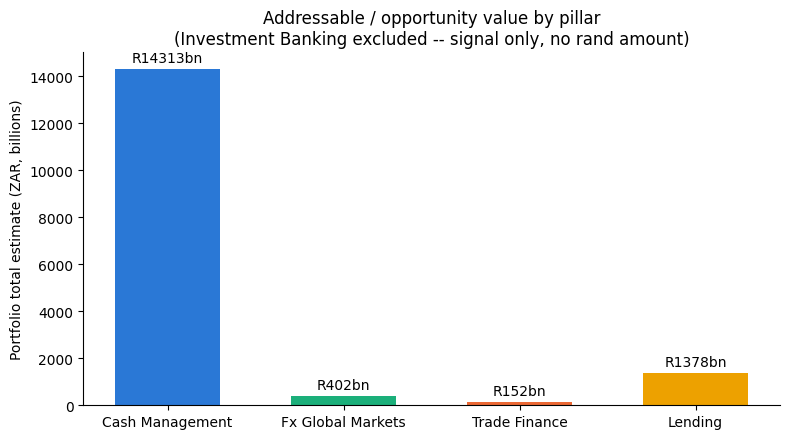

In [19]:
portfolio = con.execute(
    "SELECT product, total_estimate_zar FROM portfolio_summary WHERE product != 'investment_banking'"
).df().set_index("product")

fig, ax = plt.subplots(figsize=(8, 4.5))
values = [portfolio.loc[p, "total_estimate_zar"] / 1e9 for p in PILLAR_ORDER if p in portfolio.index]
labels = [p.replace("_", " ").title() for p in PILLAR_ORDER if p in portfolio.index]
colors = [PILLAR_COLOR[p] for p in PILLAR_ORDER if p in portfolio.index]
bars = ax.bar(labels, values, color=colors, width=0.6)
ax.bar_label(bars, fmt="R%.0fbn", padding=3)
ax.set_ylabel("Portfolio total estimate (ZAR, billions)")
ax.set_title("Addressable / opportunity value by pillar\n(Investment Banking excluded -- signal only, no rand amount)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
if _IN_NOTEBOOK:
    plt.show()

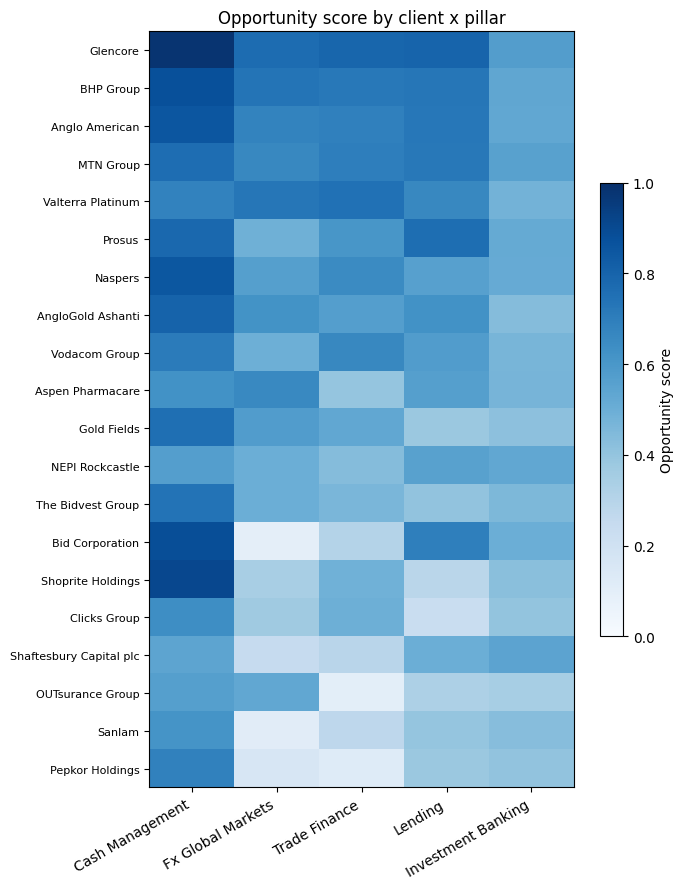

In [20]:
heatmap_data = con.execute(
    "SELECT entity_name, product, opportunity_score FROM opportunities"
).df().pivot(index="entity_name", columns="product", values="opportunity_score")
heatmap_data = heatmap_data[PILLAR_ORDER]
heatmap_data = heatmap_data.loc[heatmap_data.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(7, 9))
im = ax.imshow(heatmap_data.values, cmap="Blues", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels([c.replace("_", " ").title() for c in heatmap_data.columns], rotation=30, ha="right")
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index, fontsize=8)
ax.set_title("Opportunity score by client x pillar")
fig.colorbar(im, ax=ax, label="Opportunity score", shrink=0.6)
plt.tight_layout()
if _IN_NOTEBOOK:
    plt.show()

## 5. Where this goes next

- The live, interactive version of both charts above -- plus a client
  drill-down and a grounded AI briefing-note generator -- is
  `dashboard/app.py` (`streamlit run dashboard/app.py`).
- Competitor-lender evidence extraction and the briefing-note prompt are in
  `prompts/`, with the generating code in `src/syn_wallet/`.
- Every diagnostic and modelling caveat referenced above (`diagnostic_flags`,
  `explanation`) is published in full in `model_diagnostics.parquet` and
  `MODEL_REPORT.md`.